In [22]:
#importing functions 
import networkx as nx
from dataclasses import dataclass
from typing import Any, Dict
import time
import statistics
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm
import copy

In [23]:
#BUILDING ZX GRAPH & Z-SPIDER FUSION RULES 

@dataclass(frozen=True)
class Phase:
    value: int = 0
    mod: int = 3
    def __add__(self, other: "Phase") -> "Phase":
        if self.mod != other.mod:
            raise ValueError("Phase mod mismatch")
        return Phase((self.value + other.value) % self.mod, self.mod)

def metrics(G: nx.MultiGraph) -> Dict[str, int]:
    kinds = [G.nodes[n].get("kind") for n in G.nodes]
    return {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "Z": sum(k == "Z" for k in kinds),
        "boundary": sum(k == "boundary" for k in kinds),
    }

def fuse_Z_pair(G: nx.MultiGraph, keep: Any, remove: Any) -> None:
    p_keep: Phase = G.nodes[keep].get("phase", Phase(0))
    p_remove: Phase = G.nodes[remove].get("phase", Phase(0))
    G.nodes[keep]["phase"] = p_keep + p_remove

    for nb in list(G.neighbors(remove)):
        if nb == keep:
            continue
        for _key, edata in list(G[remove][nb].items()):
            G.add_edge(keep, nb, etype=edata.get("etype", "plain"))

    G.remove_node(remove)

def apply_Z_fusion_fixed_pt(G: nx.MultiGraph, max_iters: int = 100000) -> int:
    fusions = 0
    for _ in range(max_iters):
        did = False
        for u, v, k, edata in list(G.edges(keys=True, data=True)):
            if not (G.has_node(u) and G.has_node(v) and G.has_edge(u, v, key=k)):
                continue
            if G.nodes[u].get("kind") == "Z" and G.nodes[v].get("kind") == "Z":
                if edata.get("etype", "plain") == "plain":
                    fuse_Z_pair(G, keep=u, remove=v)
                    fusions += 1
                    did = True
                    break
        if not did:
            break
    return fusions

In [24]:
# N-QUTRIT QFT 

#building n-qutirt QFT in ZX-framework
def build_qft_zx_graph(n: int, double_edges: bool = True) -> nx.MultiGraph:
    G = nx.MultiGraph()

    for i in range(n):
        G.add_node(f"in_q{i}", kind="boundary")

    endpoints_on_wire = {i: [] for i in range(n)}

    for i in range(n):
        for j in range(i + 1, n):
            zi = f"Z_q{i}_{i}_{j}"
            zj = f"Z_q{j}_{i}_{j}"

            G.add_node(zi, kind="Z", phase=Phase(0))
            G.add_node(zj, kind="Z", phase=Phase(0))

            endpoints_on_wire[i].append(zi)
            endpoints_on_wire[j].append(zj)

            G.add_edge(zi, zj, etype="plain")

            if double_edges and (j - i) % 2 == 0:
                G.add_edge(zi, zj, etype="plain")

    for i in range(n):
        eps_sorted = sorted(endpoints_on_wire[i])

        for a, b in zip(eps_sorted, eps_sorted[1:]):
            G.add_edge(a, b, etype="plain")

        if eps_sorted:
            G.add_edge(f"in_q{i}", eps_sorted[0], etype="hadamard")

    return G

#running experiment for different n's 
def run_qft_zx(ns=(3, 5, 8, 10, 15, 20), trials=20, warmup=5) -> pd.DataFrame:
    rows = []

    for n in ns:
        trial_times = []
        before_last = None
        after_last = None
        fusions_last = None

        for _ in range(warmup):
            G = build_qft_zx_graph(n, double_edges=True)
            apply_Z_fusion_fixed_pt(G)

        for _ in range(trials):
            G = build_qft_zx_graph(n, double_edges=True)
            before = metrics(G)

            t0 = time.perf_counter()
            fusions = apply_Z_fusion_fixed_pt(G)
            t1 = time.perf_counter()

            after = metrics(G)

            trial_times.append((t1 - t0) * 1e3)
            before_last = before
            after_last = after
            fusions_last = fusions

        rows.append({"n_qutrits": n,
            "Z_before": before_last["Z"],
            "Z_after": after_last["Z"],
            "fusions": fusions_last,
            "time (ms)": round(statistics.mean(trial_times), 3),})

    return pd.DataFrame(rows)

In [25]:
#TABLE OF n-qutrit QFT ZX RESULTS 
df = run_qft_zx()
print(df.to_string(index=False))

 n_qutrits  Z_before  Z_after  fusions  time (ms)
         3         6        1        5      0.114
         5        20        1       19      0.673
         8        56        1       55      1.919
        10        90        1       89      2.954
        15       210        1      209     14.870
        20       380        1      379     47.126


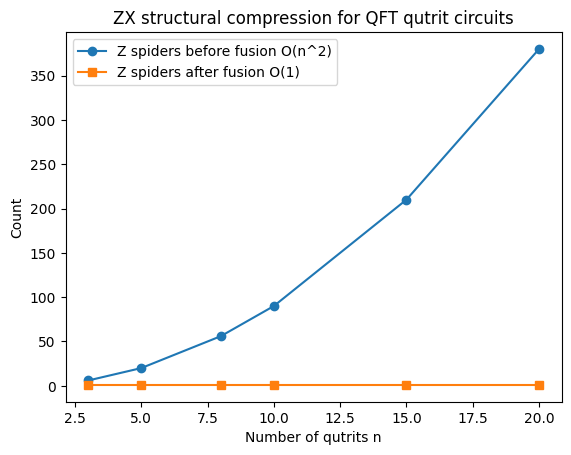

In [26]:
# PLOT OF n-qutrit QFT RESULTS 
plt.figure()
plt.plot(df["n_qutrits"], df["Z_before"], marker="o", label="Z spiders before fusion O(n^2)")
plt.plot(df["n_qutrits"], df["Z_after"], marker="s", label="Z spiders after fusion O(1)")
plt.xlabel("Number of qutrits n")
plt.ylabel("Count")
plt.title("ZX structural compression for QFT qutrit circuits")
plt.legend()
plt.show()

In [27]:
#VALIDATION CHECK I: STRUCTURAL VALIDATION OF THE QFT ZX CONSTRUCTION

def validate_qft_graph_construction(ns=(2, 3, 4, 5, 6), double_edges=True):
    rows = []

    for n in ns:
        G = build_qft_zx_graph(n, double_edges=double_edges)
        m = metrics(G)

        expected_boundaries = n
        expected_Z = n * (n - 1)   # = 2 * C(n,2)
        expected_hadamards = n

        had_edges = 0
        plain_edges = 0
        for _, _, _, edata in G.edges(keys=True, data=True):
            etype = edata.get("etype")
            if etype == "hadamard":
                had_edges += 1
            elif etype == "plain":
                plain_edges += 1

        rows.append({"n_qutrits": n,
            "boundary_actual": m["boundary"],
            "boundary_expected": expected_boundaries,
            "boundary_match": m["boundary"] == expected_boundaries,
            "Z_actual": m["Z"],
            "Z_expected": expected_Z,
            "Z_match": m["Z"] == expected_Z,
            "hadamard_actual": had_edges,
            "hadamard_expected": expected_hadamards,
            "hadamard_match": had_edges == expected_hadamards,
            "plain_edges": plain_edges,
            "nodes_total": m["nodes"],
            "edges_total": m["edges"]})

    return pd.DataFrame(rows)


df_construct_val = validate_qft_graph_construction(ns=(2, 3, 4, 5, 6), double_edges=True)

df_bool = df_construct_val[["n_qutrits", "boundary_match", "Z_match", "hadamard_match"]].rename(columns={
    "n_qutrits": "n",
    "boundary_match": "boundary",
    "Z_match": "Z",
    "hadamard_match": "H",})
print("Validating Structure of QFT Diagram")
print(df_bool.to_string(index=False))


def validate_qft_wire_participation(ns=(2, 3, 4, 5, 6), double_edges=True):
    rows = []

    for n in ns:
        G = build_qft_zx_graph(n, double_edges=double_edges)

        for i in range(n):
            count_i = sum(
                1
                for node in G.nodes
                if G.nodes[node].get("kind") == "Z"
                and str(node).startswith(f"Z_q{i}_"))

            rows.append({"n_qutrits": n,
                "wire": i,
                "Z_endpoints_on_wire": count_i,
                "expected": n - 1,
                "match": count_i == (n - 1)})

    return pd.DataFrame(rows)


df_wire_val = validate_qft_wire_participation(ns=(2, 3, 4, 5, 6), double_edges=True)
print(df_wire_val.to_string(index=False))

Validating Structure of QFT Diagram
 n  boundary    Z    H
 2      True True True
 3      True True True
 4      True True True
 5      True True True
 6      True True True
 n_qutrits  wire  Z_endpoints_on_wire  expected  match
         2     0                    1         1   True
         2     1                    1         1   True
         3     0                    2         2   True
         3     1                    2         2   True
         3     2                    2         2   True
         4     0                    3         3   True
         4     1                    3         3   True
         4     2                    3         3   True
         4     3                    3         3   True
         5     0                    4         4   True
         5     1                    4         4   True
         5     2                    4         4   True
         5     3                    4         4   True
         5     4                    4         4   True
 

In [28]:
#VALIDATION CHECK II: NUMERICAL VALIDATION OF Z-SPIDER FUSION RULE 

#z-spider tensor
omega = np.exp(2j * np.pi / 3)

def z_spider_tensor(num_legs: int, phase: int = 0) -> np.ndarray:
    T = np.zeros((3,) * num_legs, dtype=complex)
    for x in range(3):
        T[(x,) * num_legs] = omega**((phase % 3) * x)
    return T

def two_spider_connected_tensor(left_ext: int, right_ext: int,
                                phase_left: int = 0, phase_right: int = 0) -> np.ndarray:
    A = z_spider_tensor(left_ext + 1, phase_left)   # +1 for internal connection
    B = z_spider_tensor(right_ext + 1, phase_right)

    # contract internal leg: last leg of A with first leg of B
    T = np.tensordot(A, B, axes=([-1], [0]))
    return T

def fused_spider_tensor(left_ext: int, right_ext: int,
                        phase_left: int = 0, phase_right: int = 0) -> np.ndarray:
    return z_spider_tensor(left_ext + right_ext, (phase_left + phase_right) % 3)

def validate_z_fusion_local():
    rows = []

    test_cases = [(1, 1), (2, 1), (1, 2), (2, 2), (3, 1)]

    for left_ext, right_ext in test_cases:
        for p1 in range(3):
            for p2 in range(3):
                T_before = two_spider_connected_tensor(left_ext, right_ext, p1, p2)
                T_after  = fused_spider_tensor(left_ext, right_ext, p1, p2)

                fro_err = np.linalg.norm(T_before - T_after)
                max_err = np.max(np.abs(T_before - T_after))

                rows.append({"left_ext": left_ext,
                    "right_ext": right_ext,
                    "phase_left": p1,
                    "phase_right": p2,
                    "fro_error": fro_err,
                    "max_abs_error": max_err})

    return pd.DataFrame(rows)

df_fusion_val = validate_z_fusion_local()
print("Numerical Validation of Z-Spider Fusion Rule")
print(df_fusion_val.to_string(index=False))

Numerical Validation of Z-Spider Fusion Rule
 left_ext  right_ext  phase_left  phase_right    fro_error  max_abs_error
        1          1           0            0 0.000000e+00   0.000000e+00
        1          1           0            1 0.000000e+00   0.000000e+00
        1          1           0            2 0.000000e+00   0.000000e+00
        1          1           1            0 0.000000e+00   0.000000e+00
        1          1           1            1 0.000000e+00   0.000000e+00
        1          1           1            2 1.144383e-15   1.016122e-15
        1          1           2            0 0.000000e+00   0.000000e+00
        1          1           2            1 1.162129e-15   1.012539e-15
        1          1           2            2 1.077832e-15   9.550500e-16
        2          1           0            0 0.000000e+00   0.000000e+00
        2          1           0            1 0.000000e+00   0.000000e+00
        2          1           0            2 0.000000e+00   0.0000

In [29]:
#TROTTERIZING HAMILTONIAN: H = alphaZ + betaX

#Exact & Strang-splitting evolution

omega = np.exp(2j * np.pi / 3)    #n=3 root of unity 

Z = np.diag([1, omega, omega**2])
X = np.array([
    [0, 0, 1],
    [1, 0, 0],
    [0, 1, 0]], dtype=complex)


def U_exact(alpha: float, beta: float, t: float) -> np.ndarray:
    H = alpha * Z + beta * X
    return expm(-1j * t * H)


def U_strang(alpha: float, beta: float, t: float, r: int) -> np.ndarray:
    Uz_half = expm(-1j * (alpha * t / (2 * r)) * Z)
    Ux = expm(-1j * (beta * t / r) * X)
    step = Uz_half @ Ux @ Uz_half

    U = np.eye(3, dtype=complex)
    for _ in range(r):
        U = U @ step
    return U


def strang_error(alpha: float, beta: float, t: float, r: int) -> float:
    Ue = U_exact(alpha, beta, t)
    Ut = U_strang(alpha, beta, t, r)

    # Align global phase before taking the matrix norm
    phi = np.angle(np.trace(Ue.conj().T @ Ut))
    Ut_aligned = Ut * np.exp(-1j * phi)

    return np.linalg.norm(Ue - Ut_aligned)

In [30]:
# ZX FRAMEWORK FOR H = alphaZ + betaX

@dataclass(frozen=True)
class Phase:
    value: int = 0
    mod: int = 3

    def __add__(self, other: "Phase") -> "Phase":
        if self.mod != other.mod:
            raise ValueError("Phase mod mismatch")
        return Phase((self.value + other.value) % self.mod, self.mod)


def metrics(G: nx.MultiGraph) -> Dict[str, int]:
    kinds = [G.nodes[n].get("kind") for n in G.nodes]
    return {"nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "Z": sum(k == "Z" for k in kinds),
        "X": sum(k == "X" for k in kinds),
        "boundary": sum(k == "boundary" for k in kinds)}


def fuse_Z_pair(G: nx.MultiGraph, keep: Any, remove: Any) -> None:
    theta_keep = G.nodes[keep].get("theta", 0.0)
    theta_remove = G.nodes[remove].get("theta", 0.0)
    G.nodes[keep]["theta"] = theta_keep + theta_remove

    for nb in list(G.neighbors(remove)):
        if nb == keep:
            continue
        for _, edata in list(G[remove][nb].items()):
            G.add_edge(keep, nb, etype=edata.get("etype", "plain"))

    G.remove_node(remove)


def apply_Z_fusion_to_fixed_point(G: nx.MultiGraph, max_iters: int = 100000) -> int:
    fusions = 0

    for _ in range(max_iters):
        did_fuse = False

        for u, v, k, edata in list(G.edges(keys=True, data=True)):
            if not (G.has_node(u) and G.has_node(v) and G.has_edge(u, v, key=k)):
                continue

            if (G.nodes[u].get("kind") == "Z"
                and G.nodes[v].get("kind") == "Z"
                and edata.get("etype", "plain") == "plain"):
                fuse_Z_pair(G, keep=u, remove=v)
                fusions += 1
                did_fuse = True
                break

        if not did_fuse:
            break

    return fusions


def build_strang_1qutrit_zx_graph(alpha: float, beta: float, t: float, r: int) -> nx.MultiGraph:
    G = nx.MultiGraph()

    theta_z = alpha * t / (2 * r)
    theta_x = beta * t / r

    G.add_node("in_q0", kind="boundary")
    G.add_node("out_q0", kind="boundary")

    previous = "in_q0"

    for step in range(r):
        z1 = f"Z_{step}_a"
        x1 = f"X_{step}"
        z2 = f"Z_{step}_b"

        G.add_node(z1, kind="Z", theta=theta_z)
        G.add_node(x1, kind="X", theta=theta_x)
        G.add_node(z2, kind="Z", theta=theta_z)

        G.add_edge(previous, z1, etype="plain")
        G.add_edge(z1, x1, etype="plain")
        G.add_edge(x1, z2, etype="plain")

        previous = z2

    G.add_edge(previous, "out_q0", etype="plain")
    return G

In [31]:
# TROTTERIZATION OVER TIME STEPS 

def strang_zx_summary(alpha: float, beta: float, t: float, rs):
    rows = []

    for r in rs:
        G_before = build_strang_1qutrit_zx_graph(alpha, beta, t, r)
        before = metrics(G_before)

        G_after = copy.deepcopy(G_before)
        fusions = apply_Z_fusion_to_fixed_point(G_after)
        after = metrics(G_after)

        rows.append({"r": r,"before": before,"after": after,"fusions": fusions,})

    return rows
    
#assigning parameter values 
alpha = 1.0
beta = 0.7
t = 1.0

#storing data 
rs_error = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 60]
errors = [strang_error(alpha, beta, t, r) for r in rs_error]

rs_zx = [1, 2, 3, 5, 8, 10, 15, 20]
rows = strang_zx_summary(alpha, beta, t, rs_zx)

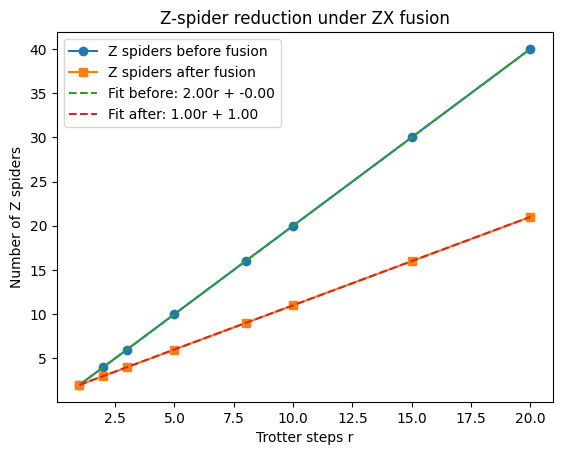

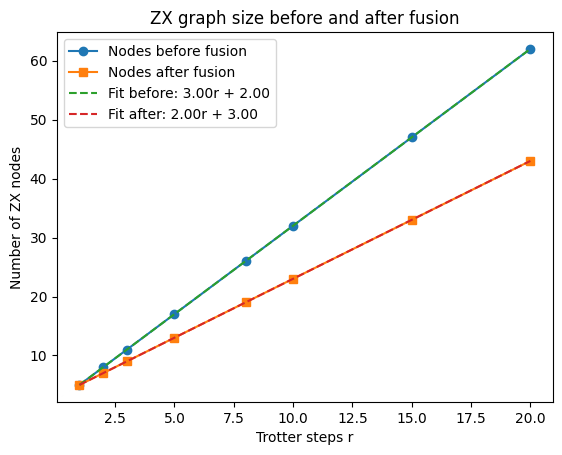

In [32]:
# ZX REDUCTION PLOTS  

r_vals = np.array([row["r"] for row in rows])
Z_before = np.array([row["before"]["Z"] for row in rows])
Z_after = np.array([row["after"]["Z"] for row in rows])

nodes_before = np.array([row["before"]["nodes"] for row in rows])
nodes_after = np.array([row["after"]["nodes"] for row in rows])

# Linear fits
slope_before, intercept_before = np.polyfit(r_vals, Z_before, 1)
slope_after, intercept_after = np.polyfit(r_vals, Z_after, 1)

slope_nb, intercept_nb = np.polyfit(r_vals, nodes_before, 1)
slope_na, intercept_na = np.polyfit(r_vals, nodes_after, 1)

fit_before = slope_before * r_vals + intercept_before
fit_after = slope_after * r_vals + intercept_after

fit_nb = slope_nb * r_vals + intercept_nb
fit_na = slope_na * r_vals + intercept_na

# Z-spider plot
plt.figure()
plt.plot(r_vals, Z_before, marker="o", label="Z spiders before fusion")
plt.plot(r_vals, Z_after, marker="s", label="Z spiders after fusion")
plt.plot(r_vals, fit_before, "--", label=f"Fit before: {slope_before:.2f}r + {intercept_before:.2f}")
plt.plot(r_vals, fit_after, "--", label=f"Fit after: {slope_after:.2f}r + {intercept_after:.2f}")
plt.xlabel("Trotter steps r")
plt.ylabel("Number of Z spiders")
plt.title("Z-spider reduction under ZX fusion")
plt.legend()
plt.show()

# Node plot
plt.figure()
plt.plot(r_vals, nodes_before, marker="o", label="Nodes before fusion")
plt.plot(r_vals, nodes_after, marker="s", label="Nodes after fusion")
plt.plot(r_vals, fit_nb, "--", label=f"Fit before: {slope_nb:.2f}r + {intercept_nb:.2f}")
plt.plot(r_vals, fit_na, "--", label=f"Fit after: {slope_na:.2f}r + {intercept_na:.2f}")
plt.xlabel("Trotter steps r")
plt.ylabel("Number of ZX nodes")
plt.title("ZX graph size before and after fusion")
plt.legend()
plt.show()

In [33]:
# TABLE OF ZX REDUCTION VALUES 

print("ZX simplification results")
print(" r | Z_before | Z_after | Z_reduction(%) | nodes_before | nodes_after | node_reduction(%)")
print("---|----------|---------|----------------|--------------|-------------|------------------")

for row in rows:
    r = row["r"]
    z_before = row["before"]["Z"]
    z_after = row["after"]["Z"]
    n_before = row["before"]["nodes"]
    n_after = row["after"]["nodes"]

    z_red = 100 * (z_before - z_after) / z_before
    node_red = 100 * (n_before - n_after) / n_before

    print(
        f"{r:>2d} | {z_before:>8d} | {z_after:>7d} | {z_red:>14.2f} | "
        f"{n_before:>12d} | {n_after:>11d} | {node_red:>16.2f}")

ZX simplification results
 r | Z_before | Z_after | Z_reduction(%) | nodes_before | nodes_after | node_reduction(%)
---|----------|---------|----------------|--------------|-------------|------------------
 1 |        2 |       2 |           0.00 |            5 |           5 |             0.00
 2 |        4 |       3 |          25.00 |            8 |           7 |            12.50
 3 |        6 |       4 |          33.33 |           11 |           9 |            18.18
 5 |       10 |       6 |          40.00 |           17 |          13 |            23.53
 8 |       16 |       9 |          43.75 |           26 |          19 |            26.92
10 |       20 |      11 |          45.00 |           32 |          23 |            28.12
15 |       30 |      16 |          46.67 |           47 |          33 |            29.79
20 |       40 |      21 |          47.50 |           62 |          43 |            30.65


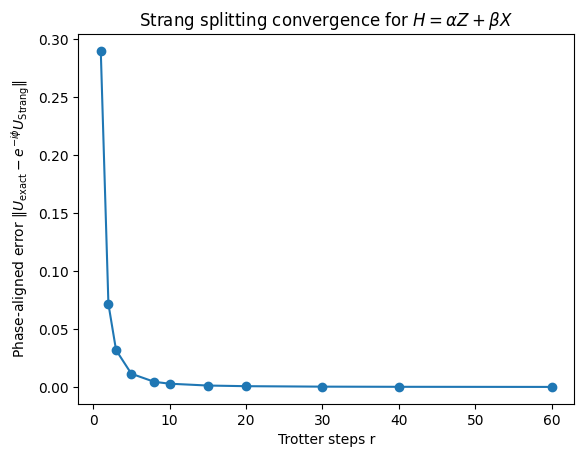

In [34]:
# VALIDATION CHECK: Trotterized Hamiltonian Converges to Original 

plt.figure()
plt.plot(rs_error, errors, marker="o")
plt.xlabel("Trotter steps r")
plt.ylabel(r"Phase-aligned error $\|U_{\mathrm{exact}} - e^{-i\phi}U_{\mathrm{Strang}}\|$")
plt.title(r"Strang splitting convergence for $H=\alpha Z+\beta X$")
plt.show()

In [35]:
# TROTTERIZING ENTANGLING HAMILTONIAN: H = alpha (Z⊗Z) + beta (X⊗I)

#Exact & Strang-Splitting Evolution
I3 = np.eye(3, dtype=complex)

ZZ_2q = np.kron(Z, Z)
X0_2q = np.kron(X, I3)


def U_exact_entangling(alpha: float, beta: float, t: float) -> np.ndarray:
    H = alpha * ZZ_2q + beta * X0_2q
    return expm(-1j * t * H)


def U_strang_entangling(alpha: float, beta: float, t: float, r: int) -> np.ndarray:
    Uzz_half = expm(-1j * (alpha * t / (2 * r)) * ZZ_2q)
    Ux0 = expm(-1j * (beta * t / r) * X0_2q)

    step = Uzz_half @ Ux0 @ Uzz_half
    U = np.eye(9, dtype=complex)

    for _ in range(r):
        U = U @ step

    return U


def strang_error_entangling(alpha: float, beta: float, t: float, r: int) -> float:
    Ue = U_exact_entangling(alpha, beta, t)
    Ut = U_strang_entangling(alpha, beta, t, r)

    # Align global phase before taking the matrix norm
    phi = np.angle(np.trace(Ue.conj().T @ Ut))
    Ut_aligned = Ut * np.exp(-1j * phi)

    return np.linalg.norm(Ue - Ut_aligned)

In [36]:
# ZX FRAMEWORK FOR ENTANGLING HAMILTONIAN 

def build_strang_2qutrit_zx_graph(alpha: float, beta: float, t: float, r: int) -> nx.MultiGraph:
    G = nx.MultiGraph()

    theta_zz = alpha * t / (2 * r)
    theta_x = beta * t / r

    G.add_node("in_q0", kind="boundary")
    G.add_node("in_q1", kind="boundary")
    G.add_node("out_q0", kind="boundary")
    G.add_node("out_q1", kind="boundary")

    prev_q0 = "in_q0"
    prev_q1 = "in_q1"

    for step in range(r):
        z_a_q0 = f"Z_{step}_a_q0"
        z_a_q1 = f"Z_{step}_a_q1"
        x_q0 = f"X_{step}_q0"
        z_b_q0 = f"Z_{step}_b_q0"
        z_b_q1 = f"Z_{step}_b_q1"

        G.add_node(z_a_q0, kind="Z", theta=theta_zz)
        G.add_node(z_a_q1, kind="Z", theta=theta_zz)
        G.add_node(x_q0, kind="X", theta=theta_x)
        G.add_node(z_b_q0, kind="Z", theta=theta_zz)
        G.add_node(z_b_q1, kind="Z", theta=theta_zz)

        # q0 wire
        G.add_edge(prev_q0, z_a_q0, etype="plain")
        G.add_edge(z_a_q0, x_q0, etype="plain")
        G.add_edge(x_q0, z_b_q0, etype="plain")

        # q1 wire
        G.add_edge(prev_q1, z_a_q1, etype="plain")
        G.add_edge(z_a_q1, z_b_q1, etype="plain")

        # entangling ZZ structure
        G.add_edge(z_a_q0, z_a_q1, etype="plain")
        G.add_edge(z_b_q0, z_b_q1, etype="plain")

        prev_q0 = z_b_q0
        prev_q1 = z_b_q1

    G.add_edge(prev_q0, "out_q0", etype="plain")
    G.add_edge(prev_q1, "out_q1", etype="plain")

    return G

In [37]:
# TROTTERIZATION OVER TIME STEPS

def strang_entangling_summary(alpha: float, beta: float, t: float, rs):
    rows = []

    for r in rs:
        G_before = build_strang_2qutrit_zx_graph(alpha, beta, t, r)
        before = metrics(G_before)

        G_after = copy.deepcopy(G_before)
        fusions = apply_Z_fusion_to_fixed_point(G_after)
        after = metrics(G_after)

        rows.append({"r": r,
            "before": before,
            "after": after,
            "fusions": fusions})

    return rows

#assigned parameter values
alpha = 1.0
beta = 0.7
t = 1.0

rs_error_ent = [1, 2, 3, 5, 8, 10, 15, 20, 30, 40, 60]
errors_ent = [strang_error_entangling(alpha, beta, t, r) for r in rs_error_ent]

rs_zx_ent = [1, 2, 3, 5, 8, 10, 15, 20]
rows_ent = strang_entangling_summary(alpha, beta, t, rs_zx_ent)

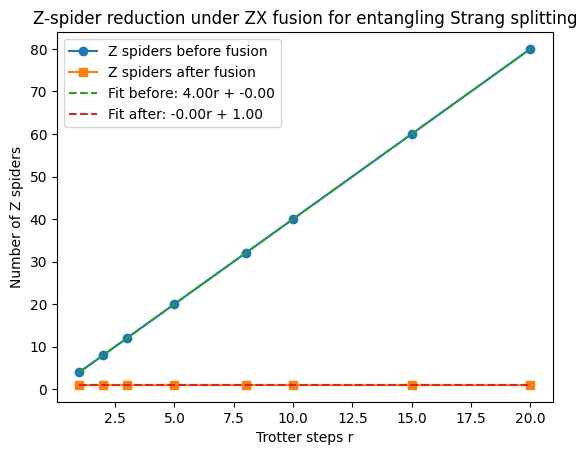

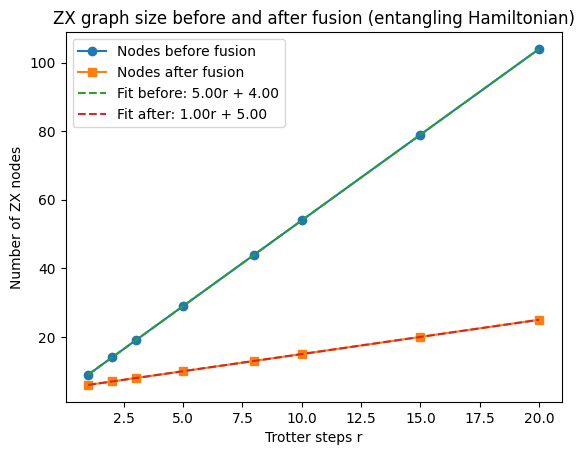

In [38]:
# ZX REDUCTION PLOTS

r_vals_ent = np.array([row["r"] for row in rows_ent])
Z_before_ent = np.array([row["before"]["Z"] for row in rows_ent])
Z_after_ent = np.array([row["after"]["Z"] for row in rows_ent])

nodes_before_ent = np.array([row["before"]["nodes"] for row in rows_ent])
nodes_after_ent = np.array([row["after"]["nodes"] for row in rows_ent])

# Linear fits
slope_be, intercept_be = np.polyfit(r_vals_ent, Z_before_ent, 1)
slope_ae, intercept_ae = np.polyfit(r_vals_ent, Z_after_ent, 1)

slope_nbe, intercept_nbe = np.polyfit(r_vals_ent, nodes_before_ent, 1)
slope_nae, intercept_nae = np.polyfit(r_vals_ent, nodes_after_ent, 1)

fit_be = slope_be * r_vals_ent + intercept_be
fit_ae = slope_ae * r_vals_ent + intercept_ae

fit_nbe = slope_nbe * r_vals_ent + intercept_nbe
fit_nae = slope_nae * r_vals_ent + intercept_nae

# Z-spider plot
plt.figure()
plt.plot(r_vals_ent, Z_before_ent, marker="o", label="Z spiders before fusion")
plt.plot(r_vals_ent, Z_after_ent, marker="s", label="Z spiders after fusion")
plt.plot(r_vals_ent, fit_be, "--", label=f"Fit before: {slope_be:.2f}r + {intercept_be:.2f}")
plt.plot(r_vals_ent, fit_ae, "--", label=f"Fit after: {slope_ae:.2f}r + {intercept_ae:.2f}")
plt.xlabel("Trotter steps r")
plt.ylabel("Number of Z spiders")
plt.title("Z-spider reduction under ZX fusion for entangling Strang splitting")
plt.legend()
plt.show()

# Node plot
plt.figure()
plt.plot(r_vals_ent, nodes_before_ent, marker="o", label="Nodes before fusion")
plt.plot(r_vals_ent, nodes_after_ent, marker="s", label="Nodes after fusion")
plt.plot(r_vals_ent, fit_nbe, "--", label=f"Fit before: {slope_nbe:.2f}r + {intercept_nbe:.2f}")
plt.plot(r_vals_ent, fit_nae, "--", label=f"Fit after: {slope_nae:.2f}r + {intercept_nae:.2f}")
plt.xlabel("Trotter steps r")
plt.ylabel("Number of ZX nodes")
plt.title("ZX graph size before and after fusion (entangling Hamiltonian)")
plt.legend()
plt.show()

In [39]:
# ZX REDUCTION TABLE 

print("Entangling Strang ZX simplification results")
print(" r | Z_before | Z_after | Z_reduction(%) | nodes_before | nodes_after | node_reduction(%)")
print("---|----------|---------|----------------|--------------|-------------|------------------")

for row in rows_ent:
    r = row["r"]
    z_before = row["before"]["Z"]
    z_after = row["after"]["Z"]
    n_before = row["before"]["nodes"]
    n_after = row["after"]["nodes"]

    z_red = 100 * (z_before - z_after) / z_before
    node_red = 100 * (n_before - n_after) / n_before

    print(f"{r:>2d} | {z_before:>8d} | {z_after:>7d} | {z_red:>14.2f} | "
        f"{n_before:>12d} | {n_after:>11d} | {node_red:>16.2f}")

Entangling Strang ZX simplification results
 r | Z_before | Z_after | Z_reduction(%) | nodes_before | nodes_after | node_reduction(%)
---|----------|---------|----------------|--------------|-------------|------------------
 1 |        4 |       1 |          75.00 |            9 |           6 |            33.33
 2 |        8 |       1 |          87.50 |           14 |           7 |            50.00
 3 |       12 |       1 |          91.67 |           19 |           8 |            57.89
 5 |       20 |       1 |          95.00 |           29 |          10 |            65.52
 8 |       32 |       1 |          96.88 |           44 |          13 |            70.45
10 |       40 |       1 |          97.50 |           54 |          15 |            72.22
15 |       60 |       1 |          98.33 |           79 |          20 |            74.68
20 |       80 |       1 |          98.75 |          104 |          25 |            75.96


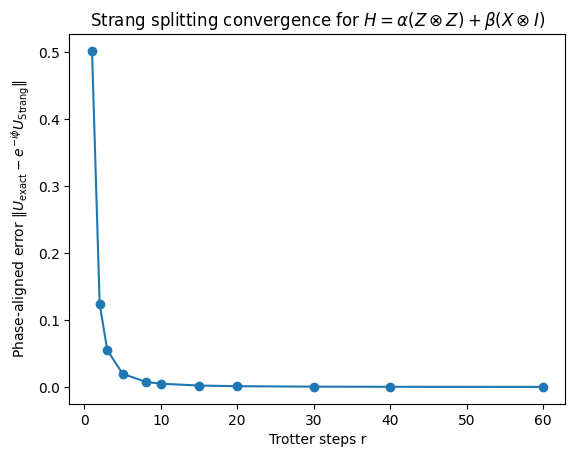

In [40]:
# VALIDATION CHECK: Trotterized Hamiltonian Converges to Original 

plt.figure()
plt.plot(rs_error_ent, errors_ent, marker="o")
plt.xlabel("Trotter steps r")
plt.ylabel(r"Phase-aligned error $\|U_{\mathrm{exact}} - e^{-i\phi}U_{\mathrm{Strang}}\|$")
plt.title(r"Strang splitting convergence for $H=\alpha(Z\otimes Z)+\beta(X\otimes I)$")
plt.show()

In [41]:
# REDUNDANCY TESTS

# POSITIVE CONTROL TEST
def add_redundant_Z(G: nx.MultiGraph, z_node: str, tag: str = "red") -> None:
    """
    Insert a zero-phase Z spider immediately after an existing Z node
    along one non-boundary outgoing edge, creating a fuseable Z-Z pair.
    """
    if G.nodes[z_node].get("kind") != "Z":
        raise ValueError(f"{z_node} is not a Z node")

    # choose one neighbor to reroute through the new redundant spider
    candidates = [nb for nb in G.neighbors(z_node)]
    if not candidates:
        raise ValueError(f"{z_node} has no neighbors")

    # prefer a non-boundary neighbor if possible
    chosen_nb = None
    for nb in candidates:
        if G.nodes[nb].get("kind") != "boundary":
            chosen_nb = nb
            break
    if chosen_nb is None:
        chosen_nb = candidates[0]

    # remove exactly one edge between z_node and chosen_nb
    edge_keys = list(G[z_node][chosen_nb].keys())
    if not edge_keys:
        raise ValueError(f"No edge found between {z_node} and {chosen_nb}")
    first_key = edge_keys[0]
    edata = dict(G[z_node][chosen_nb][first_key])

    G.remove_edge(z_node, chosen_nb, key=first_key)

    new_z = f"{z_node}_{tag}"
    G.add_node(new_z, kind="Z", theta=0.0)

    G.add_edge(z_node, new_z, etype="plain")
    G.add_edge(new_z, chosen_nb, etype=edata.get("etype", "plain"))


def fusion_redundant_case(alpha: float, beta: float, t: float, r: int) -> nx.MultiGraph:
    G = build_strang_1qutrit_zx_graph(alpha, beta, t, r)

    # add a few redundant Z spiders that your rule should remove
    add_redundant_Z(G, "Z_0_a", tag="extra1")
    if r > 1:
        add_redundant_Z(G, "Z_1_b", tag="extra2")

    return G

# running it 
alpha, beta, t, r = 1.0, 0.7, 1.0, 3

G_base = build_strang_1qutrit_zx_graph(alpha, beta, t, r)
G_pos = fusion_redundant_case(alpha, beta, t, r)

print("Base metrics:", metrics(G_base))
print("Obfuscated metrics:", metrics(G_pos))

G_pos_simpl = copy.deepcopy(G_pos)
fusions_pos = apply_Z_fusion_to_fixed_point(G_pos_simpl)

print("Simplified metrics:", metrics(G_pos_simpl))
print("Number of fusions:", fusions_pos)

Base metrics: {'nodes': 11, 'edges': 10, 'Z': 6, 'X': 3, 'boundary': 2}
Obfuscated metrics: {'nodes': 13, 'edges': 12, 'Z': 8, 'X': 3, 'boundary': 2}
Simplified metrics: {'nodes': 9, 'edges': 8, 'Z': 4, 'X': 3, 'boundary': 2}
Number of fusions: 4


In [42]:
# NEGATIVE CONTROL TEST

def add_single_X_bridge(G: nx.MultiGraph, left_node: str, right_node: str, tag: str = "neg") -> None:
    """
    Insert a single X spider between two existing nodes.
    """
    x = f"{tag}_X"

    G.add_node(x, kind="X", theta=0.0)

    G.add_edge(left_node, x, etype="plain")
    G.add_edge(x, right_node, etype="plain")
    
def X_bridge_negative_case(alpha: float, beta: float, t: float, r: int) -> nx.MultiGraph:
    G = build_strang_2qutrit_zx_graph(alpha, beta, t, r)

    # Add one X bridge between the two wires at a chosen step
    add_single_X_bridge(G, "Z_0_a_q0", "Z_0_a_q1", tag="neg0")

    if r > 1:
        add_single_X_bridge(G, "Z_1_b_q0", "Z_1_b_q1", tag="neg1")

    return G

import copy

alpha, beta, t, r = 1.0, 0.7, 1.0, 3

# baseline case
G_base = build_strang_2qutrit_zx_graph(alpha, beta, t, r)
G_base_s = copy.deepcopy(G_base)
f_base = apply_Z_fusion_to_fixed_point(G_base_s)

print("\nBASELINE")
print("Before:", metrics(G_base))
print("After: ", metrics(G_base_s))
print("Fusions:", f_base)

# negative control case
G_neg = X_bridge_negative_case(alpha, beta, t, r)
G_neg_s = copy.deepcopy(G_neg)
f_neg = apply_Z_fusion_to_fixed_point(G_neg_s)

print("\nNEGATIVE CONTROL")
print("Before:", metrics(G_neg))
print("After: ", metrics(G_neg_s))
print("Fusions:", f_neg)


BASELINE
Before: {'nodes': 19, 'edges': 23, 'Z': 12, 'X': 3, 'boundary': 4}
After:  {'nodes': 8, 'edges': 10, 'Z': 1, 'X': 3, 'boundary': 4}
Fusions: 11

NEGATIVE CONTROL
Before: {'nodes': 21, 'edges': 27, 'Z': 12, 'X': 5, 'boundary': 4}
After:  {'nodes': 10, 'edges': 14, 'Z': 1, 'X': 5, 'boundary': 4}
Fusions: 11
